### MLC-2 Lab-02/02/2026

In [1]:
import numpy as np
X=np.array([[1,2],[2,1],[3,4],[5,7],[6,8],[7,6],[8,5],[4,3]])
print(X)

[[1 2]
 [2 1]
 [3 4]
 [5 7]
 [6 8]
 [7 6]
 [8 5]
 [4 3]]


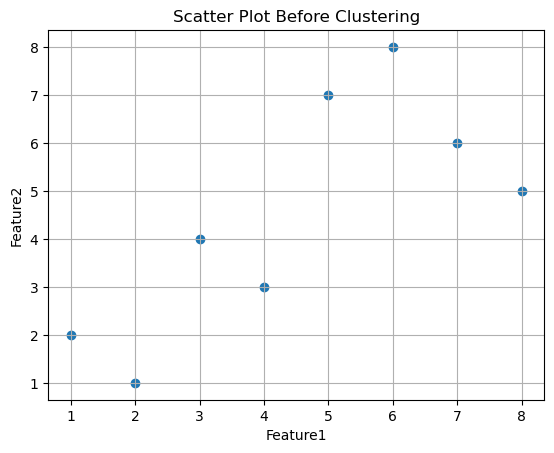

In [2]:
import matplotlib.pyplot as plt
plt.scatter(X[:,0],X[:,1])
plt.xlabel("Feature1")
plt.ylabel("Feature2")
plt.title("Scatter Plot Before Clustering")
plt.grid(True)
plt.show()

/opt/anaconda3/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


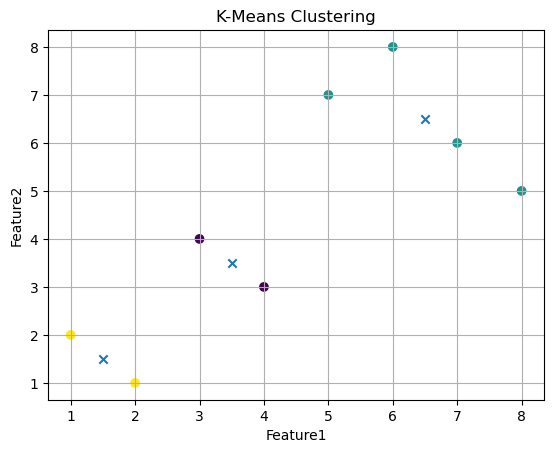

In [3]:
from sklearn.cluster import KMeans
kmeans=KMeans(n_clusters=3,random_state=42)
labels=kmeans.fit_predict(X)
plt.scatter(X[:,0],X[:,1],c=labels)
plt.scatter(kmeans.cluster_centers_[:,0],kmeans.cluster_centers_[:,1],marker='x')
plt.title("K-Means Clustering")
plt.xlabel("Feature1")
plt.ylabel("Feature2")
plt.grid(True)
plt.show()

/opt/anaconda3/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/opt/anaconda3/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/opt/anaconda3/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/opt/anaconda3/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of

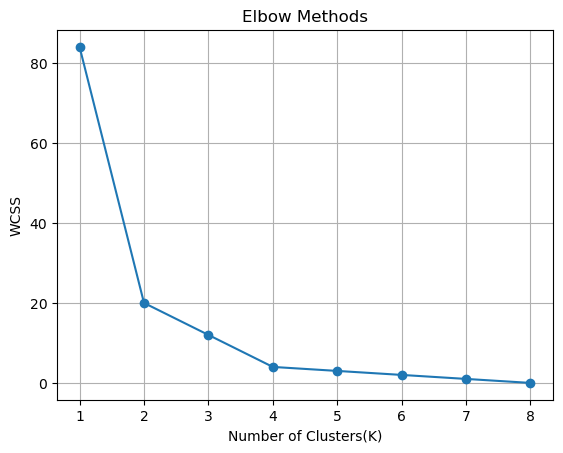

In [4]:
wcss=[]
for k in range(1,9):
    km=KMeans(n_clusters=k,random_state=42)
    km.fit(X)
    wcss.append(km.inertia_)
plt.plot(range(1,9),wcss,marker='o')
plt.xlabel("Number of Clusters(K)")
plt.ylabel("WCSS")
plt.title("Elbow Methods")
plt.grid(True)
plt.show()

### MLC-2 Lab-19/02/2026

In [1]:
pip install scikit-learn-extra

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 29.0 MB/s  0:00:00

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


/opt/anaconda3/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


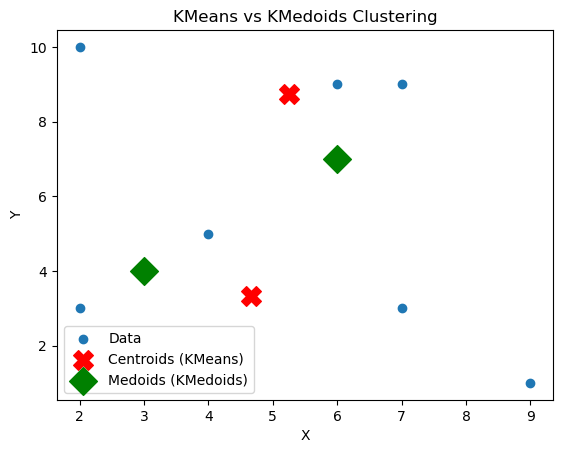

Centroids: [[4.66666667 3.33333333]
 [5.25       8.75      ]]
Medoids: [[6. 7.]
 [3. 4.]]


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn_extra.cluster import KMedoids
data=[[3,4],[2,3],[3,4],[4,5],[6,7],[7,3],[9,1],[2,10],[6,9],[7,9]]
df=pd.DataFrame(data,columns=['x','y'])
n_clusters=2
kmeans=KMeans(n_clusters=n_clusters,random_state=42)
kmeans.fit(df)
centroids=kmeans.cluster_centers_
kmedoids=KMedoids(n_clusters=n_clusters,random_state=42)
kmedoids.fit(df)
medoids=kmedoids.cluster_centers_
plt.scatter(df['x'],df['y'],label='Data')
plt.scatter(centroids[:,0],centroids[:,1],color='red',marker='X',s=200,label='Centroids (KMeans)')
plt.scatter(medoids[:,0],medoids[:,1],color='green',marker='D',s=200,label='Medoids (KMedoids)')
plt.legend()
plt.xlabel('X')
plt.ylabel('Y')
plt.title('KMeans vs KMedoids Clustering')
plt.show()
print("Centroids:",centroids)
print("Medoids:",medoids)

In [3]:
transactions=[("Bread","Milk","Butter","Salt"),("Bread","Milk","Egg","Apple"),("Bread","Milk","Butter","Apple"),("Egg","Butter","Apple"),("Bread","Egg","Salt"),("Bread","Milk","Tea","Apple")]
import pandas as pd
items=sorted(set(item for transaction in transactions for item in transaction))
data=[]
for transaction in transactions:
    row=[1 if item in transaction else 0 for item in items]
    data.append(row)
df=pd.DataFrame(data,columns=items)
df.index.name="Transaction"
print(df)

             Apple  Bread  Butter  Egg  Milk  Salt  Tea
Transaction                                            
0                0      1       1    0     1     1    0
1                1      1       0    1     1     0    0
2                1      1       1    0     1     0    0
3                1      0       1    1     0     0    0
4                0      1       0    1     0     1    0
5                1      1       0    0     1     0    1


In [6]:
def support(itemset, transactions):
    return sum(1 for t in transactions if set(itemset).issubset(t)) / len(transactions)

def confidence(X, Y, transactions):
    return support(set(X).union(Y), transactions) / support(X, transactions)

print("Support(Bread):", support(("Bread",), transactions))
print("Confidence (Bread → Milk):", confidence(("Bread",), ("Milk",), transactions))
print("Confidence (Bread, Milk → Egg):", confidence(("Bread","Milk"), ("Egg",), transactions))

Support(Bread): 0.8333333333333334
Confidence (Bread → Milk): 0.7999999999999999
Confidence (Bread, Milk → Egg): 0.25


In [7]:
min_support=0.5
transactions=[{"sport","tresnald"},{"sport"},{"tresnald"},{"sport","tresnald"}]
def support(itemset):
    return sum(1 for t in transactions if itemset.issubset(t))/len(transactions)
items=set().union(*transactions)
frequent_items=[{i} for i in items if support({i})>=min_support]
print("Frequent 1-itemsets:")
for i in frequent_items:
    print(i,"Support:",support(i))

Frequent 1-itemsets:
{'tresnald'} Support: 0.75
{'sport'} Support: 0.75
